In [25]:
from typing import TypedDict

from langgraph.graph import StateGraph, END

from langchain_groq import ChatGroq

from pydantic import BaseModel, Field

import os
import json
import subprocess

In [26]:
import os

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [27]:
from pydantic import BaseModel


class ArchitecturePlan(BaseModel):

    project_name: str

    files: list[str]

architecture_llm=llm.with_structured_output(ArchitecturePlan)

In [28]:
def architecture_agent(state):

    prompt = f"""
You are a software architect.

User Request:
{state["user_request"]}

Create a SIMPLE project structure.

Rules:

- Include main.py
- Include utils.py
- Include db.py
- Include routes.py
- Include requirements.txt
- Keep file count minimal
- Avoid overengineering
- Beginner friendly

Return:

project_name
files
"""

    result = architecture_llm.invoke(
        prompt
    )

    state["project_name"] = (
        result.project_name
    )

    state["project_files"] = (
        result.files
    )

    print("\nPROJECT:")
    print(result.project_name)

    print("\nFILES:")
    print(result.files)

    return state

In [29]:
class ProjectSpecOutput(BaseModel):

    spec: str

spec_llm = llm.with_structured_output(ProjectSpecOutput)

In [30]:
def project_spec_agent(state):

    prompt = f"""
You are a senior software architect.

User Request:
{state["user_request"]}

Files:
{state["project_files"]}

Create a project specification.

Include:

- Application Type
- Architecture Style
- Framework
- Database
- Storage
- Models
- External Dependencies
- File Responsibilities
- Coding Rules

The specification must be detailed enough
that multiple developers can build the
project consistently.
"""

    result = spec_llm.invoke(
        prompt
    )

    state["project_spec"] = (
        result.spec
    )

    print(
        "\nPROJECT SPEC CREATED"
    )

    return state

In [31]:
import os

WORKSPACE = "workspace"

def create_files_agent(state):

    project_root = os.path.join(
        WORKSPACE,
        state["project_name"]
    )

    os.makedirs(
        project_root,
        exist_ok=True
    )

    for filename in state["project_files"]:

        filepath = os.path.join(
            project_root,
            filename
        )

        os.makedirs(
            os.path.dirname(filepath),
            exist_ok=True
        )

        open(filepath, "w").close()

        print("Created:", filepath)

    return state

In [32]:
class CodeOutput(BaseModel):
    code: str

code_llm = llm.with_structured_output(CodeOutput)

In [33]:
def generate_file_agent(state):

    try:

        current_file = state["project_files"][
            state["current_file_index"]
        ]

        print(
            "Index:",
            state["current_file_index"]
        )

        print(
            "Files:",
            len(state["project_files"])
        )

        # Skip requirements.txt
        # It will be generated later by requirements agent

        if current_file == "requirements.txt":

            print(
                "Skipping requirements.txt"
            )

            state["current_file_index"] += 1

            return state

        generated_context = ""

        for file, code in state[
            "generated_code"
        ].items():

            generated_context += f"""

FILE: {file}

{code}

"""

        prompt = f"""
You are a senior Python software engineer.

User Request:
{state["user_request"]}

Project Specification:
{state["project_spec"]}

Project Files:
{state["project_files"]}

Already Generated Files:
{generated_context}

Current File:
{current_file}

Generate ONLY the code for:
{current_file}

Rules:

- Follow the project specification exactly.
- Keep imports consistent.
- Use only files listed in Project Files.
- Do not invent frameworks.
- Do not invent dependencies.
- Do not use markdown.
- Do not use code fences.
- Do not write explanations.
- Return only executable code.
- Ensure this file works with previously generated files.
"""

        result = llm.invoke(
            prompt
        )

        code = result.content

        code = code.replace(
            "```python",
            ""
        )

        code = code.replace(
            "```",
            ""
        )

        project_root = os.path.join(
            WORKSPACE,
            state["project_name"]
        )

        filepath = os.path.join(
            project_root,
            current_file
        )

        with open(
            filepath,
            "w",
            encoding="utf-8"
        ) as f:

            f.write(code)

        state["generated_code"][
            current_file
        ] = code

        print(
            f"Generated: {current_file}"
        )

        state["current_file_index"] += 1

        return state

    except Exception as e:

        print(
            "GENERATION ERROR:"
        )

        print(e)

        raise

In [34]:
## Generate Requirements
import os
import re


def generate_requirements_agent(state):

    project_root = os.path.join(
        WORKSPACE,
        state["project_name"]
    )

    imports = set()

    for filename in state["project_files"]:

        if not filename.endswith(".py"):
            continue

        filepath = os.path.join(
            project_root,
            filename
        )

        with open(filepath, "r", encoding="utf-8") as f:
            code = f.read()

        imports.update(
            re.findall(
                r"^\s*import\s+([a-zA-Z_][a-zA-Z0-9_]*)",
                code,
                re.MULTILINE
            )
        )

        imports.update(
            re.findall(
                r"^\s*from\s+([a-zA-Z_][a-zA-Z0-9_]*)\s+import",
                code,
                re.MULTILINE
            )
        )

    BUILTIN_MODULES = {
        "os",
        "sys",
        "json",
        "math",
        "time",
        "random",
        "re",
        "pathlib",
        "typing",
        "collections",
        "datetime",
        "itertools",
        "functools",
        "logging",
        "threading",
        "asyncio",
        "sqlite3"
    }

    project_modules = {

        os.path.splitext(file)[0]

        for file in state["project_files"]

        if file.endswith(".py")
    }

    requirements = sorted(

        pkg

        for pkg in imports

        if pkg not in BUILTIN_MODULES
        and pkg not in project_modules
    )

    requirements_path = os.path.join(
        project_root,
        "requirements.txt"
    )

    with open(
        requirements_path,
        "w",
        encoding="utf-8"
    ) as f:

        f.write(
            "\n".join(requirements)
        )

    print(
        "Generated requirements.txt"
    )

    print(requirements)

    return state


In [36]:
## VAlidation
import os
import subprocess
import sys


def validation_agent(state):

    project_root = os.path.join(
        WORKSPACE,
        state["project_name"]
    )

    state["has_error"] = False

    for filename in state["project_files"]:

        filepath = os.path.join(
            project_root,
            filename
        )

        print(
            f"Validating {filename}"
        )

        result = subprocess.run(
            [
                sys.executable,
                "-m",
                "py_compile",
                filepath
            ],
            capture_output=True,
            text=True
        )
        print("Return Code:", result.returncode)
        print("STDERR:")
        print(result.stderr)
                
        

        if result.returncode != 0:

            print(
                f"Validation Failed: {filename}"
            )

            print(result.stderr)

            state["errors"].append(
                result.stderr
            )

            state["has_error"] = True

            return state

    print(
        "Validation Success"
    )

    return state

In [37]:
## Dependency installing agent

import os
import subprocess
import sys


def dependency_agent(state):

    project_root = os.path.join(
        WORKSPACE,
        state["project_name"]
    )

    requirements_path = os.path.join(
        project_root,
        "requirements.txt"
    )

    if not os.path.exists(
        requirements_path
    ):

        print(
            "requirements.txt not found"
        )

        return state

    print(
        "\nInstalling Dependencies..."
    )

    result = subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-r",
            requirements_path
        ],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:

        print(
            "Dependency Installation Failed"
        )

        print(
            result.stderr
        )

        state["errors"].append(
            result.stderr
        )

        state["has_error"] = True

    else:

        print(
            "Dependencies Installed"
        )

        print(
            result.stdout
        )

    return state


In [38]:
### Run Agent

import os
import sys
import time
import subprocess


def run_agent(state):

    project_root = os.path.join(
        WORKSPACE,
        state["project_name"]
    )

    main_file = os.path.join(
        project_root,
        "main.py"
    )

    print(
        f"Running {main_file}"
    )

    process = subprocess.Popen(
        [
            sys.executable,
            main_file
        ],
        # cwd=project_root,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True
    )

    time.sleep(5)

    # PROCESS STILL RUNNING
    if process.poll() is None:

        print(
            "Application Started Successfully"
        )

        state["execution_logs"].append(
            "Application Started"
        )

        state["server_pid"] = (
            process.pid
        )

        state["has_error"] = False

        return state

    # PROCESS EXITED
    stdout, stderr = (
        process.communicate()
    )

    if process.returncode == 0:

        print(
            "Execution Success"
        )

        print(stdout)

        state["execution_logs"].append(
            stdout
        )

        state["has_error"] = False

    else:

        print(
            "Execution Failed"
        )

        print(stderr)

        state["errors"].append(
            stderr
        )

        state["has_error"] = True

    return state

In [60]:
from pydantic import BaseModel


class FileFix(BaseModel):
    filename: str
    code: str


class DebugOutput(BaseModel):

    root_cause: str

    fixes: list[FileFix]

debug_llm = llm.with_structured_output(
    DebugOutput
)

In [78]:
import os


def debug_agent(state):

    print("\nDEBUG AGENT RUNNING")

    if state["retry_count"] >= state["max_retries"]:

        print(
            "Maximum retries reached"
        )

        return state

    latest_error = state["errors"][-1]

    project_root = os.path.join(
        WORKSPACE,
        state["project_name"]
    )

    all_files = ""

    for filename, code in state[
        "generated_code"
    ].items():

        all_files += f"""

FILE: {filename}

{code}

"""

    prompt = f"""
You are an expert Python debugging agent.

Project Specification:

{state["project_spec"]}

Project Files:

{all_files}

Application Error:

{latest_error}

Analyze the error.

Identify the root cause.

Fix ONLY the files that need modification.

Rules:

- Return only modified files.
- Do not return unchanged files.
- Return COMPLETE corrected file content.
- No markdown.
- No code fences.
- Return executable code only.
"""

    result = debug_llm.invoke(
        prompt
    )

    print(
        "\nROOT CAUSE:"
    )

    print(
        result.root_cause
    )

    if not result.fixes:

        print(
            "No fixes returned"
        )

        state["retry_count"] += 1

        return state

    for fix in result.fixes:

        filepath = os.path.join(
            project_root,
            fix.filename
        )

        with open(
            filepath,
            "w",
            encoding="utf-8"
        ) as f:

            f.write(fix.code)

        state["generated_code"][
            fix.filename
        ] = fix.code

        print(
            f"Fixed: {fix.filename}"
        )

    state["retry_count"] += 1

    state["has_error"] = False

    print(
        "Debug completed"
    )

    return state

In [54]:
def validation_router(state):

    if state["retry_count"] >= state["max_retries"]:
        return "finish"

    if state["has_error"]:

        return "debug"

    return "dependency"

In [53]:
def run_router(state):

    if state["retry_count"] >= state["max_retries"]:
        return "finish"

    if state["has_error"]:

        return "debug"

    return "finish"

In [47]:
def file_router(state):

    if (
        state["current_file_index"]
        <
        len(state["project_files"])
    ):
        return "generate"

    return "requirements"

In [61]:
def dependency_router(state):

    if state["retry_count"] >= state["max_retries"]:
        return "finish"

    if state["has_error"]:
        return "debug"

    return "run"

In [43]:
from typing import TypedDict


class AgentState(TypedDict):

    user_request: str

    project_name: str

    project_files: list

    project_spec: str

    current_file_index: int

    generated_code: dict

    installed_dependencies: list

    validation_logs: list

    execution_logs: list

    errors: list

    has_error: bool

    retry_count: int

    max_retries: int

    server_pid: int | None

    final_output: str

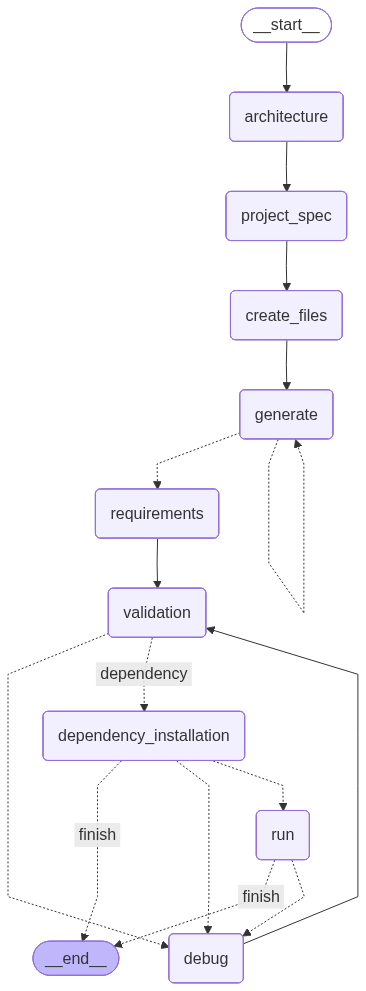

In [62]:
from langgraph.graph import StateGraph
from langgraph.graph import END

graph = StateGraph(
    AgentState
)

graph.add_node(
    "architecture",
    architecture_agent
)

graph.add_node(
    "project_spec",
    project_spec_agent
)

graph.add_node(
    "create_files",
    create_files_agent
)

graph.add_node(
    "generate",
    generate_file_agent
)

graph.add_node(
    "requirements",
    generate_requirements_agent
)

graph.add_node(
    "validation",
    validation_agent
)

graph.add_node(
    "dependency_installation",
    dependency_agent
)
graph.add_node(
    "run",
    run_agent
)

graph.add_node(
    "debug",
    debug_agent
)

graph.set_entry_point(
    "architecture"
)

graph.add_edge(
    "architecture",
    "project_spec"
)

graph.add_edge(
    "project_spec",
    "create_files"
)

graph.add_edge(
    "create_files",
    "generate"
)

graph.add_conditional_edges(
    "generate",
    file_router,
    {
        "generate": "generate",
        "requirements": "requirements"
    }
)

graph.add_edge(
    "requirements",
    "validation"
)

graph.add_conditional_edges(
    "validation",
    validation_router,
    {
        "debug": "debug",
        "dependency": "dependency_installation"
    }
)

graph.add_conditional_edges(
    "dependency_installation",
    dependency_router,
    {
        "debug": "debug",
        "run": "run",
        "finish": END
    }
)

graph.add_conditional_edges(
    "run",
    run_router,
    {
        "debug": "debug",
        "finish": END
    }
)
graph.add_edge(
    "debug",
    "validation"
)


app = graph.compile()
app

In [65]:
state = {

    # User Request
    "user_request":
    "Create a web app in flask with crud apis dont use database connection as of now just hardcode some data and reurn from the apis",

    # Architecture
    "project_name": "",

    "project_files": [],

    "project_spec": "",

    # Generation
    "current_file_index": 0,

    "generated_code": {},

    # Requirements / Dependency
    "installed_dependencies": [],

    # Validation
    "validation_logs": [],

    # Run
    "execution_logs": [],

    "server_pid": None,

    # Error Handling
    "errors": [],

    "has_error": False,

    # Debug Loop
    "retry_count": 0,

    "max_retries": 3,

    # Final Output
    "final_output": ""

}

In [64]:
state = app.invoke(state)


PROJECT:
flask_crud_app

FILES:
['main.py', 'utils.py', 'db.py', 'routes.py', 'requirements.txt']

PROJECT SPEC CREATED
Created: workspace\flask_crud_app\main.py
Created: workspace\flask_crud_app\utils.py
Created: workspace\flask_crud_app\db.py
Created: workspace\flask_crud_app\routes.py
Created: workspace\flask_crud_app\requirements.txt
Index: 0
Files: 5
Generated: main.py
Index: 1
Files: 5
Generated: utils.py
Index: 2
Files: 5
Generated: db.py
Index: 3
Files: 5
Generated: routes.py
Index: 4
Files: 5
Skipping requirements.txt
Generated requirements.txt
['flask']
Validating main.py
Return Code: 0
STDERR:

Validating utils.py
Return Code: 0
STDERR:

Validating db.py
Return Code: 0
STDERR:

Validating routes.py
Return Code: 0
STDERR:

Validating requirements.txt
Return Code: 0
STDERR:

Validation Success

Installing Dependencies...
Dependencies Installed

Running workspace\flask_crud_app\main.py
Application Started Successfully
